# Modelado de Series Temporales: SARIMA

En base al análisis exploratorio previo (test ADF estacionario, pero con fuerte estacionalidad anual en enfermedades respiratorias), aplicaremos el modelo **SARIMA** (Seasonal Autoregressive Integrated Moving Average).

Separaremos la serie temporal dejando el último año (52 semanas) como conjunto de prueba (test set) para evaluar qué tan bien el modelo puede predecir "el futuro" comparado con los datos reales que ya tenemos.

In [1]:
%pip install pandas numpy matplotlib statsmodels scikit-learn pmdarima

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar y preparar los datos (mismo proceso que en explore)
df = pd.read_parquet('dataset_limpios/at_urg_respiratorio_limpio.parquet')

def get_date_from_iso_week(year, week):
    date_str = f'{year}-W{week:02d}-1' 
    try:
        return datetime.strptime(date_str, '%G-W%V-%u')
    except ValueError:
        return datetime(year, 12, 31)

df['Fecha'] = df.apply(lambda row: get_date_from_iso_week(int(row['Anio']), int(row['SemanaEstadistica'])), axis=1)

ts_df = df.groupby('Fecha')['NumTotal'].sum().reset_index()
ts_df.set_index('Fecha', inplace=True)
ts_df.sort_index(inplace=True)

# Asignar frecuencia semanal explícita para evitar advertencias de Statsmodels
ts_df = ts_df.asfreq('W-MON')
# Rellenar valores nulos (si hubiera semanas omitidas) con el método ffill (forward fill) o interpolación lineal
ts_df['NumTotal'] = ts_df['NumTotal'].interpolate(method='linear')

print("Datos preparados. Frecuencia de la serie indexada:\n", ts_df.head(2))

Datos preparados. Frecuencia de la serie indexada:
             NumTotal
Fecha               
2013-12-30   37369.0
2014-01-06   59069.0


In [30]:
# 2. Dividir los datos en Entrenamiento (Train) y Prueba (Test)
# Entrenar desde el 2022 hasta el 2025, y testear solo con el año 2026.

train = ts_df[(ts_df.index.year >= 2014) & (ts_df.index.year <= 2024)]
test = ts_df[ts_df.index.year == 2025]

test_size = len(test)

print(f"Fechas de Entrenamiento: desde {train.index.min().date()} hasta {train.index.max().date()}")
print(f"Fechas de Prueba (Test): desde {test.index.min().date()} hasta {test.index.max().date()}")
print(f"Semanas en entrenamiento: {len(train)}")
print(f"Semanas en prueba (test): {test_size}")

Fechas de Entrenamiento: desde 2014-01-06 hasta 2024-12-30
Fechas de Prueba (Test): desde 2025-01-06 hasta 2025-12-29
Semanas en entrenamiento: 574
Semanas en prueba (test): 52


In [31]:
# 3. Entrenamiento del Modelo SARIMA
# Parámetros:
# order=(p, d, q): Componente no estacional. d=0 porque confirmamos estacionariedad con test ADF. p=1 y q=1 como punto de partida clásico.
# seasonal_order=(P, D, Q, m): Componente estacional. m=52 (semanas en el año). D=1 para diferenciar la estacionalidad anual.
print("Entrenando modelo SARIMA, esto puede tardar un momento...")

model = SARIMAX(train['NumTotal'], 
                order=(1, 0, 1),
                seasonal_order=(1, 1, 1, 52),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print("¡Entrenamiento finalizado!")
print(results.summary())

Entrenando modelo SARIMA, esto puede tardar un momento...
¡Entrenamiento finalizado!
                                     SARIMAX Results                                      
Dep. Variable:                           NumTotal   No. Observations:                  574
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 52)   Log Likelihood               -4963.091
Date:                            Mon, 11 May 2026   AIC                           9936.181
Time:                                    02:18:41   BIC                           9956.923
Sample:                                01-06-2014   HQIC                          9944.343
                                     - 12-30-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9615      0.

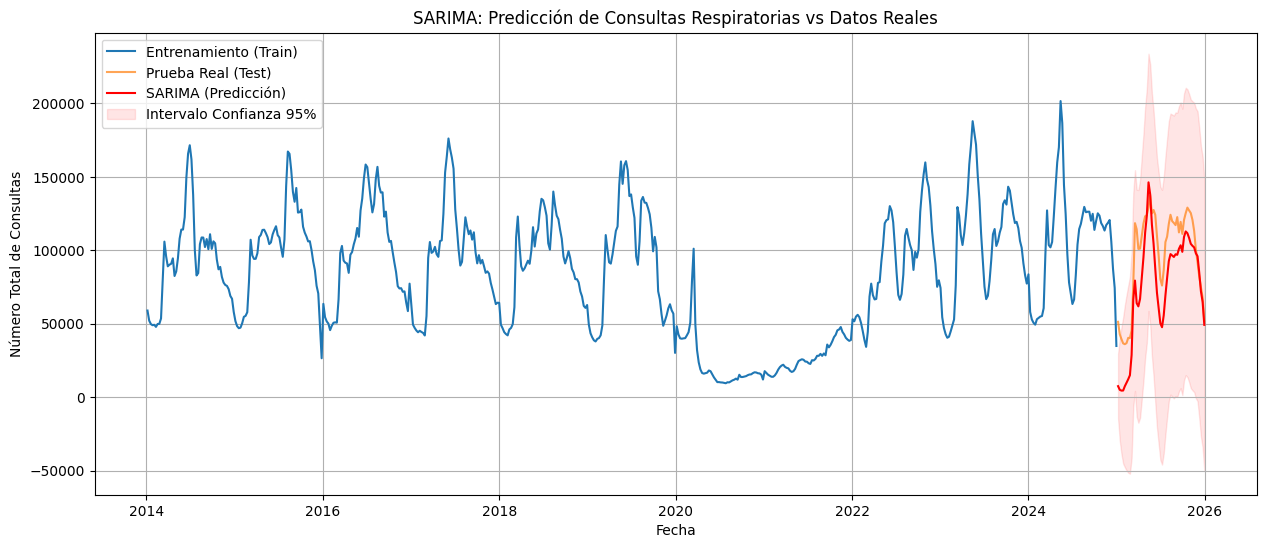

In [32]:
# 4. Predicción y Visualización

# Predecir los próximos 'test_size' pasos (las 52 semanas del set de testeo)
predictions = results.get_forecast(steps=test_size)
pred_mean = predictions.predicted_mean
pred_ci = predictions.conf_int() # Intervalos de confianza

plt.figure(figsize=(15, 6))

# Graficar Train
plt.plot(train.index, train['NumTotal'], label='Entrenamiento (Train)')
# Graficar Test real
plt.plot(test.index, test['NumTotal'], label='Prueba Real (Test)', alpha=0.7)
# Graficar Predicción
plt.plot(pred_mean.index, pred_mean, color='red', label='SARIMA (Predicción)')

# Sombreado de Intervalos de Confianza (95%)
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1], color='red', alpha=0.1, label='Intervalo Confianza 95%')

plt.title('SARIMA: Predicción de Consultas Respiratorias vs Datos Reales')
plt.xlabel('Fecha')
plt.ylabel('Número Total de Consultas')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# 5. Evaluación del Modelo (Métricas)

# Para calcular el error solo comparamos sobre las fechas en donde tenemos test reales (ignoramos NaNs)
test_y = test['NumTotal'].dropna()
pred_clean = pred_mean.loc[test_y.index]

rmse = np.sqrt(mean_squared_error(test_y, pred_clean))
mae = mean_absolute_error(test_y, pred_clean)
mape = mean_absolute_percentage_error(test_y, pred_clean)

print("=== Métricas de Rendimiento sobre Set de Prueba ===")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Error Absoluto Medio (MAE):               {mae:.2f}")
print(f"Error Absoluto Porcentual (MAPE):         {mape*100:.2f}%")

=== Métricas de Rendimiento sobre Set de Prueba ===
Raíz del Error Cuadrático Medio (RMSE): 25130.47
Error Absoluto Medio (MAE):               21826.73
Error Absoluto Porcentual (MAPE):         28.16%
